WYBOR I ANALIZA DATASETU

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path
import torch 
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from dataclasses import dataclass
import hashlib


In [3]:
dataset = ImageFolder("data")
print(dataset.classes)

classes = dataset.classes
rows = []

for path, label in dataset.samples:
    img = cv2.imread(path)
    digest = hashlib.md5(Path(path).read_bytes()).hexdigest()

    if img is None:
        rows.append({'path': path, 'class': classes[label], 'broken': True, 'hash': digest})
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rows.append({
        'path': path,
        'class': classes[label],
        'broken': False,
        'width': img.shape[1],
        'height': img.shape[0],
        'brightness': gray.mean(),
        'contrast': gray.std(),
        'sharpness': cv2.Laplacian(gray, cv2.CV_64F).var(),
        'hash': digest
    })

df = pd.DataFrame(rows)

print(f"Wszystkich zdjęć: {len(df)}")
print(f"Duplikaty zdjęć: {df['hash'].duplicated().sum()}")
print("\nZdjęcia per klasa:")
print(df['class'].value_counts())
print("\nRozmiary zdjęć (szerokość × wysokość):")
print(df.loc[~df['broken']].groupby(['width', 'height']).size().sort_values(ascending=False))

# rows = []
# for c in classes:
#     for p in glob(f'data/{c}/*.jpg'):
#         img = cv2.imread(p)
#         if img is None: #obsluga bledu imread lub to nie jest .jpg
#             rows.append({'path': p, 'class': c, 'broken': True})
#             continue
#         gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)#konwertowanie na szare do liczenia jasnosci kontrastu i ostrosci
#         rows.append({'path': p, 'class': c, 'broken': False, 'width': img.shape[1], 'height': img.shape[0],
#                      'brightness': gray.mean(), 'contrast': gray.std(),
#                      'sharpness': cv2.Laplacian(gray, cv2.CV_64F).var(),
#                      'hash': hashlib.md5(open(p, 'rb').read()).hexdigest()})

# df = pd.DataFrame(rows)
# print(f"head : \n{df.head()}")
# print(f"ilosc zdj : {len(df)}")
# print(f"zepsute : {df['broken'].sum()}")
# print(f"duplikaty : {df.duplicated('hash').sum()}")
# print(f"klasy : \n{df['class'].value_counts()}")

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Wszystkich zdjęć: 2527
Duplikaty zdjęć: 3

Zdjęcia per klasa:
class
paper        594
glass        501
plastic      482
metal        410
cardboard    403
trash        137
Name: count, dtype: int64

Rozmiary zdjęć (szerokość × wysokość):
width  height
512    384       2527
dtype: int64


In [4]:

df = df[df['broken'] == False].copy()
df = df.drop_duplicates(subset='hash', keep='first').reset_index(drop=True)

print(f"po usunięciu duplikatów: {len(df)}")

print(df[['width', 'height', 'brightness', 'contrast', 'sharpness']].describe())
print(df.groupby('class')[['brightness', 'contrast', 'sharpness']].mean().round(1))

po usunięciu duplikatów: 2524
        width  height   brightness     contrast    sharpness
count  2524.0  2524.0  2524.000000  2524.000000  2524.000000
mean    512.0   384.0   164.674676    46.374020   334.871038
std       0.0     0.0    20.005435    15.505422   438.627002
min     512.0   384.0    77.998515     7.494097     2.049306
25%     512.0   384.0   153.581912    34.923092    69.923313
50%     512.0   384.0   168.403058    45.064001   173.763745
75%     512.0   384.0   177.686162    57.465299   404.359458
max     512.0   384.0   224.416036    98.731349  4127.156033
           brightness  contrast  sharpness
class                                     
cardboard       152.8      45.5      231.0
glass           171.4      47.4      170.1
metal           158.7      54.6      380.8
paper           165.8      48.1      625.5
plastic         170.3      37.6      227.4
trash           168.0      43.7      222.1


Wszystkie maja 512x384, jasnosc dosyc wysoka pewnie przez tlo, trash ma mniej zdjec od innych klas

CZYSZCZENIE

In [5]:
df = (
    df.loc[~df["broken"]]
    .drop_duplicates(subset="hash", keep="first")
    .reset_index(drop=True)
    .copy()
)

print(f"Po oczyszczeniu zostaje {len(df)} zdjęć")


Po oczyszczeniu zostaje 2524 zdjęć


/var/folders/j3/k3dkzcqd7msfw4nb3b1605hh0000gn/T/ipykernel_51807/3151426869.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


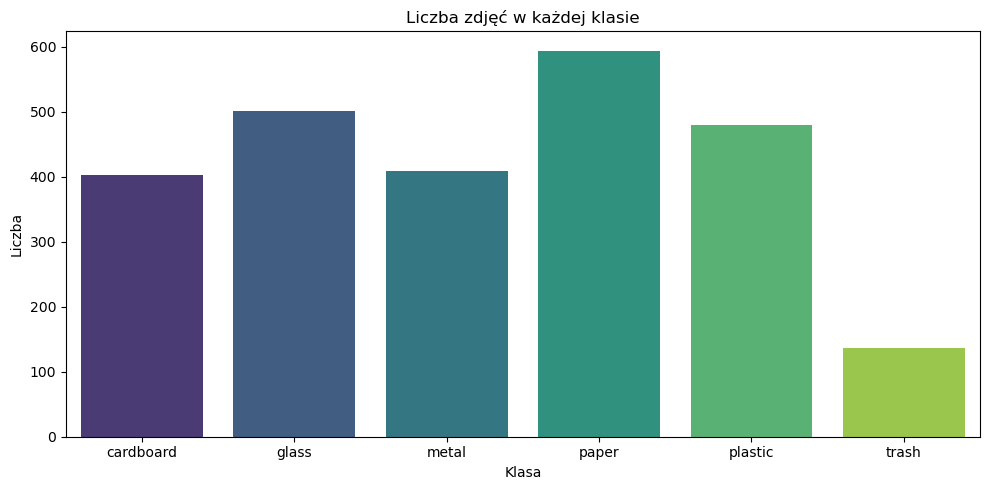

In [6]:
counts = df["class"].value_counts().reindex(classes, fill_value=0)

plt.figure(figsize=(10, 5))
sns.barplot(x=counts.index, y=counts.values, palette="viridis")
plt.title("Liczba zdjęć w każdej klasie")
plt.xlabel("Klasa")
plt.ylabel("Liczba")
plt.tight_layout()
plt.show()

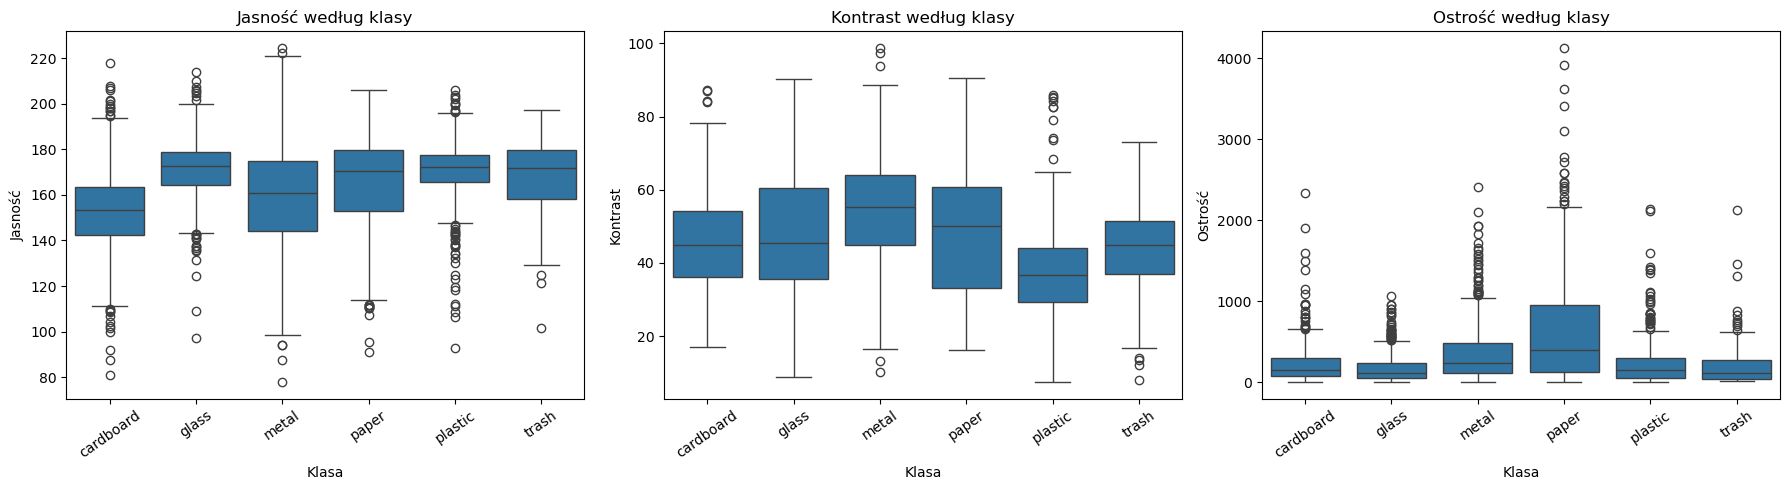

In [7]:
features = ["brightness", "contrast", "sharpness"]
titles = {
    "brightness": "Jasność",
    "contrast": "Kontrast",
    "sharpness": "Ostrość",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, features):
    sns.boxplot(data=df, x="class", y=feature, order=classes, ax=ax)
    ax.set_title(f"{titles[feature]} według klasy")
    ax.set_xlabel("Klasa")
    ax.set_ylabel(titles[feature])
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

Dataset 2


In [8]:
dataset2 = ImageFolder("data2")
print(dataset2.classes)

classes = dataset2.classes
rows = []

for path, label in dataset2.samples:
    img = cv2.imread(path)
    digest = hashlib.md5(Path(path).read_bytes()).hexdigest()

    if img is None:
        rows.append({'path': path, 'class': classes[label], 'broken': True, 'hash': digest})
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rows.append({
        'path': path,
        'class': classes[label],
        'broken': False,
        'width': img.shape[1],
        'height': img.shape[0],
        'brightness': gray.mean(),
        'contrast': gray.std(),
        'sharpness': cv2.Laplacian(gray, cv2.CV_64F).var(),
        'hash': digest
    })

df2 = pd.DataFrame(rows)

print(f"Wszystkich zdjęć: {len(df2)}")
print(f"Duplikaty zdjęć: {df2['hash'].duplicated().sum()}")
print("\nZdjęcia per klasa:")
print(df2['class'].value_counts())
print("\nRozmiary zdjęć (szerokość × wysokość):")
print(df2.loc[~df2['broken']].groupby(['width', 'height']).size().sort_values(ascending=False))


['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Wszystkich zdjęć: 7463
Duplikaty zdjęć: 0

Zdjęcia per klasa:
class
glass        1736
plastic      1597
cardboard    1411
paper        1336
metal         930
trash         453
Name: count, dtype: int64

Rozmiary zdjęć (szerokość × wysokość):
width  height
384    384       7463
dtype: int64


/var/folders/j3/k3dkzcqd7msfw4nb3b1605hh0000gn/T/ipykernel_51807/4106393916.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


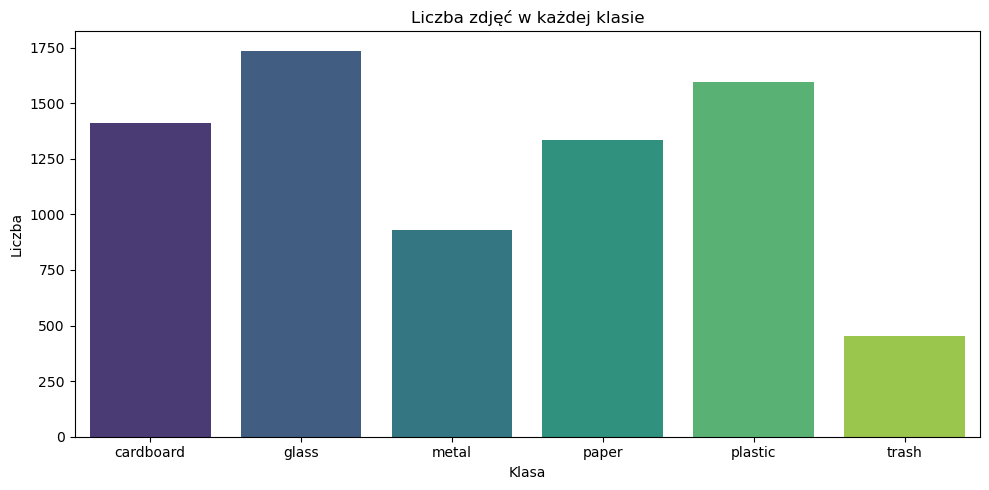

In [9]:
counts = df2["class"].value_counts().reindex(classes, fill_value=0)

plt.figure(figsize=(10, 5))
sns.barplot(x=counts.index, y=counts.values, palette="viridis")
plt.title("Liczba zdjęć w każdej klasie")
plt.xlabel("Klasa")
plt.ylabel("Liczba")
plt.tight_layout()
plt.show()

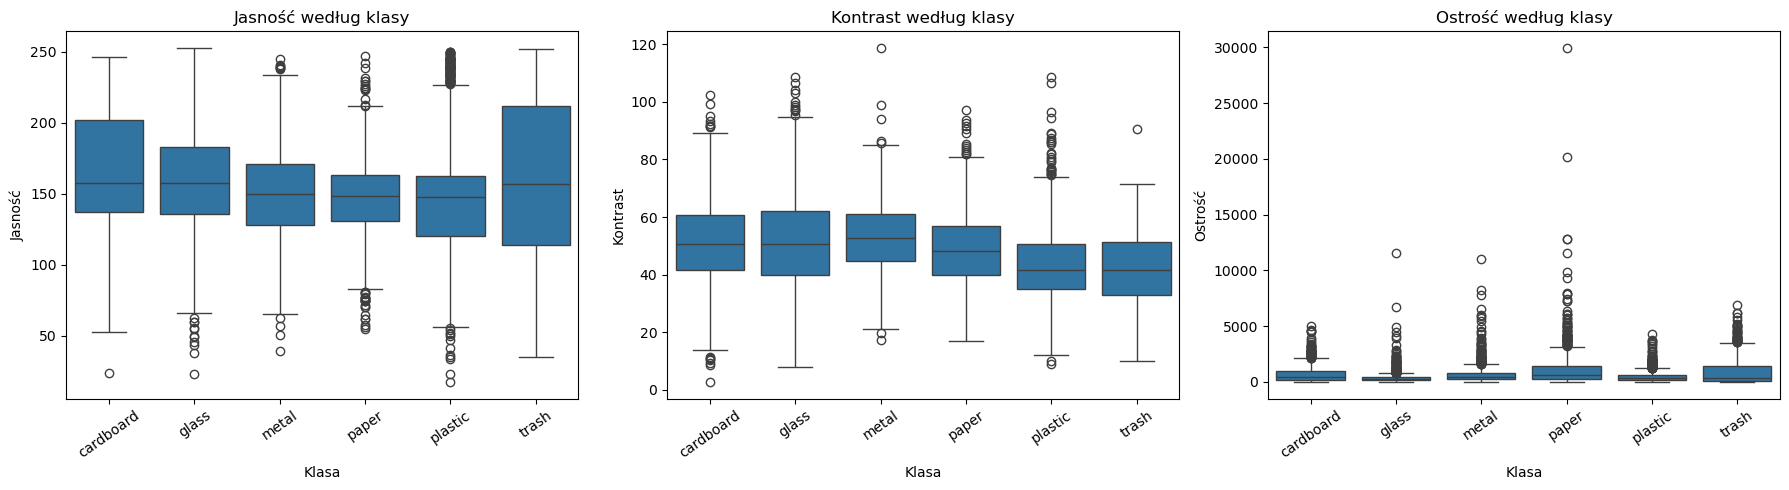

In [10]:
features = ["brightness", "contrast", "sharpness"]
titles = {
    "brightness": "Jasność",
    "contrast": "Kontrast",
    "sharpness": "Ostrość",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, features):
    sns.boxplot(data=df2, x="class", y=feature, order=classes, ax=ax)
    ax.set_title(f"{titles[feature]} według klasy")
    ax.set_xlabel("Klasa")
    ax.set_ylabel(titles[feature])
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

Dataset 1 po czyszczeniu: 2524 zdjęć
Dataset 2 po czyszczeniu: 7463 zdjęć
Identyczne pliki obecne w obu datasetach: 0


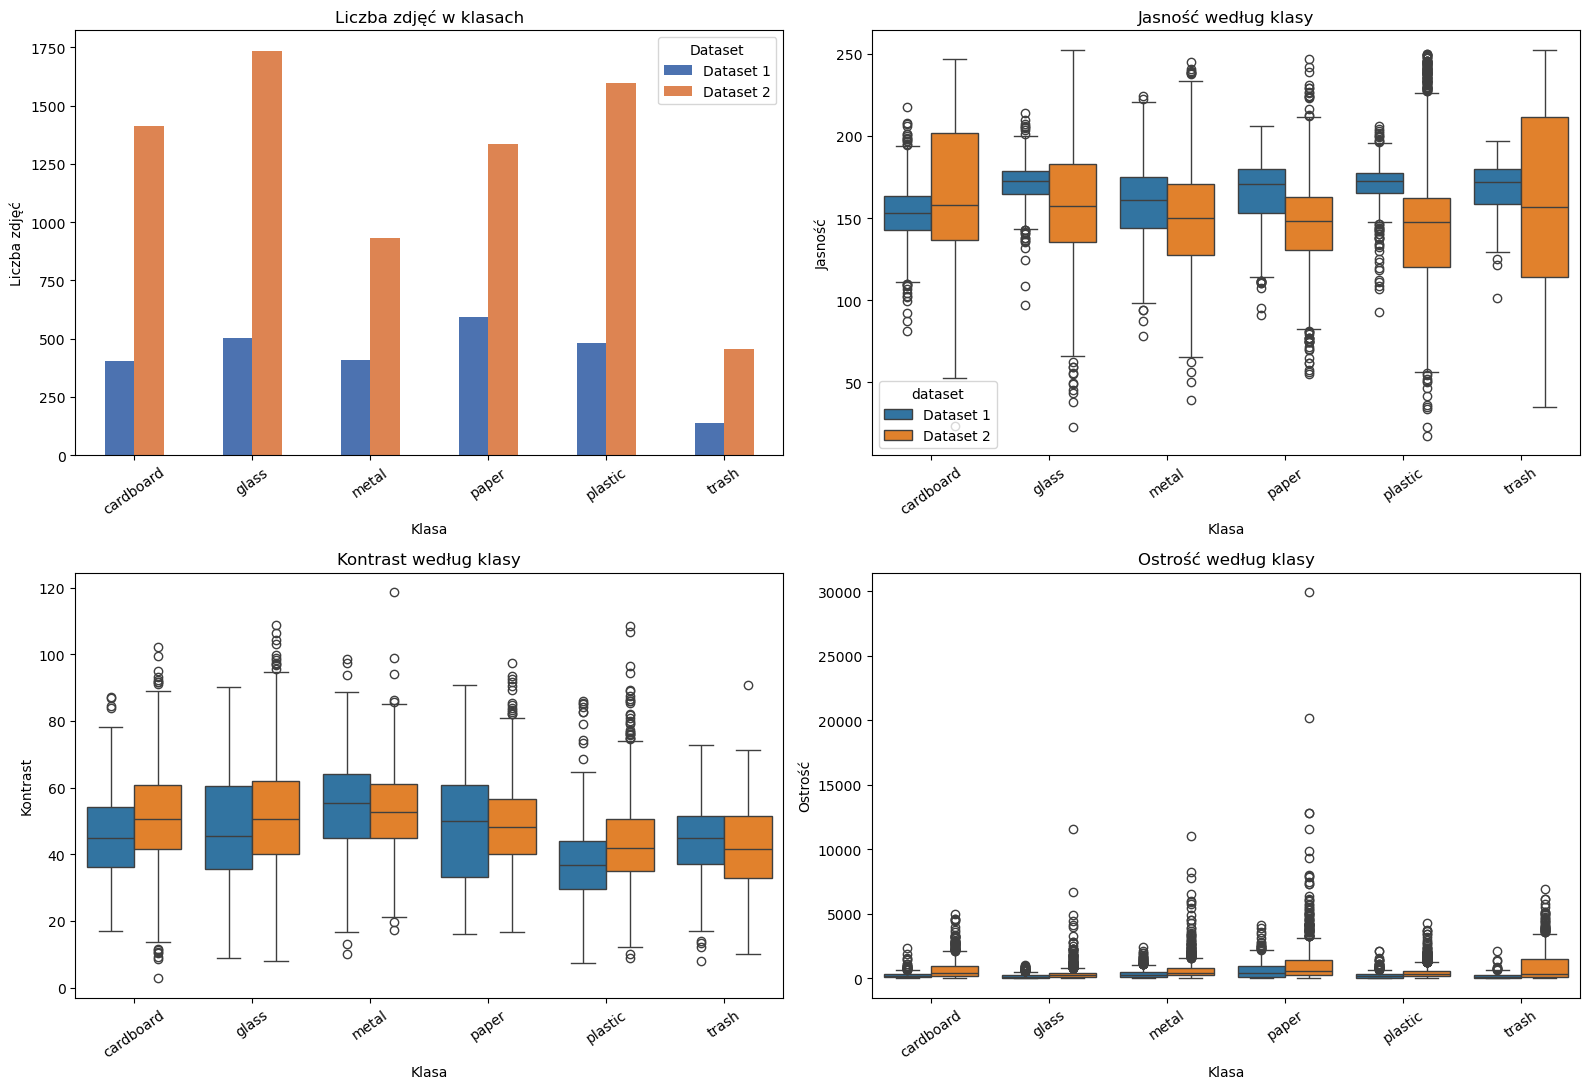

In [13]:
# porównanie dwóch datasetów obok siebie 
df1_compare = (
    df.loc[~df["broken"]]
    .drop_duplicates(subset="hash")
    .assign(dataset="Dataset 1")
)
df2_compare = (
    df2.loc[~df2["broken"]]
    .drop_duplicates(subset="hash")
    .assign(dataset="Dataset 2")
)

comparison = pd.concat([df1_compare, df2_compare], ignore_index=True)
dataset_order = ["Dataset 1", "Dataset 2"]
class_order = sorted(comparison["class"].unique())

print(f"Dataset 1 po czyszczeniu: {len(df1_compare)} zdjęć")
print(f"Dataset 2 po czyszczeniu: {len(df2_compare)} zdjęć")
print(
    "Identyczne pliki obecne w obu datasetach:",
    len(set(df1_compare["hash"]) & set(df2_compare["hash"]))
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Liczba zdjęć w poszczególnych klasach
class_counts = (
    pd.crosstab(comparison["class"], comparison["dataset"])
    .reindex(index=class_order, columns=dataset_order, fill_value=0)
)
class_counts.plot(kind="bar", ax=axes[0, 0], color=["#4C72B0", "#DD8452"])
axes[0, 0].set_title("Liczba zdjęć w klasach")
axes[0, 0].set_xlabel("Klasa")
axes[0, 0].set_ylabel("Liczba zdjęć")
axes[0, 0].tick_params(axis="x", rotation=35)
axes[0, 0].legend(title="Dataset")

# Porównanie właściwości obrazów
feature_titles = {
    "brightness": "Jasność",
    "contrast": "Kontrast",
    "sharpness": "Ostrość",
}

for ax, (feature, title) in zip(
    [axes[0, 1], axes[1, 0], axes[1, 1]],
    feature_titles.items()
):
    sns.boxplot(
        data=comparison,
        x="class",
        y=feature,
        hue="dataset",
        order=class_order,
        hue_order=dataset_order,
        ax=ax
    )
    ax.set_title(f"{title} według klasy")
    ax.set_xlabel("Klasa")
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=35)

    if ax is not axes[0, 1]:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

Problem ? 
Rózne wymiary obrazow w dwoch datasetach
bardzo zroznicowane jasnosc, kontrast oraz ostrosc co moze wplynac potem na zachowanie modelu 
Niezbalansowane klasy w obu datasetach 

Różne źródła danych mogą prowadzić do dataset bias i domain shift, co może obniżyć zdolność modelu do generalizacji na rzeczywiste obrazy z kamery telefonu.